# Multi Checkpoint Performance Analysis

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
evaluation_dir = Path("/home/chen/thesis/Experiments/Baseline-1/evaluation")
checkpoint_pattern = re.compile(r"^eval-model_(\d+)\.csv$")

evaluation_dir


PosixPath('/home/chen/thesis/Experiments/Baseline-1/evaluation')

In [3]:
def list_checkpoint_csvs(directory: Path) -> list[tuple[int, Path]]:
    """Return sorted checkpoint csv files under one evaluation directory."""
    matches = []
    for path in directory.glob("eval-model_*.csv"):
        match = checkpoint_pattern.match(path.name)
        if match is None:
            continue
        matches.append((int(match.group(1)), path))
    return sorted(matches, key=lambda item: item[0])


def load_checkpoint_means(directory: Path) -> pd.DataFrame:
    """Load the final mean row from every checkpoint csv."""
    checkpoint_csvs = list_checkpoint_csvs(directory)
    print("Matched csv files:", [path.name for _, path in checkpoint_csvs])

    rows = []
    for checkpoint_step, csv_path in checkpoint_csvs:
        df = pd.read_csv(csv_path)
        if df.empty:
            print(f"Skip empty csv: {csv_path}")
            continue

        mean_row = df.iloc[-1]
        if str(mean_row["number"]).strip() != "mean":
            print(f"Skip csv without mean row: {csv_path}")
            continue

        rows.append(
            {
                "checkpoint": checkpoint_step,
                "collision": float(mean_row["collision"]),
                "offroad": float(mean_row["offroad"]),
                "progress": float(mean_row["progress"]),
                "position_reached": float(mean_row["position_reached"]),
                "total_episode_reward": float(mean_row["total_episode_reward"]),
            }
        )

    summary_df = pd.DataFrame(rows)
    if summary_df.empty:
        raise ValueError(f"No valid checkpoint csv files found under {directory}")

    return summary_df.sort_values("checkpoint").reset_index(drop=True)


summary_df = load_checkpoint_means(evaluation_dir)
summary_df


Matched csv files: ['eval-model_1000.csv', 'eval-model_2000.csv', 'eval-model_3000.csv', 'eval-model_4000.csv', 'eval-model_5000.csv', 'eval-model_6000.csv', 'eval-model_7000.csv', 'eval-model_8000.csv', 'eval-model_9000.csv', 'eval-model_10000.csv', 'eval-model_11000.csv', 'eval-model_12000.csv', 'eval-model_13000.csv', 'eval-model_14000.csv', 'eval-model_15000.csv', 'eval-model_16000.csv', 'eval-model_17000.csv', 'eval-model_18000.csv', 'eval-model_19000.csv', 'eval-model_20000.csv', 'eval-model_21000.csv', 'eval-model_22000.csv', 'eval-model_23000.csv', 'eval-model_24000.csv', 'eval-model_25000.csv']


,checkpoint,collision,offroad,progress,position_reached,total_episode_reward
0,1000,0.338,0.215,0.452755,0.093,110.315923
1,2000,0.346,0.263,0.604557,0.210,105.559010
2,3000,0.337,0.314,0.605682,0.165,110.534720
3,4000,0.388,0.310,0.466142,0.105,75.512767
4,5000,0.300,0.267,0.530584,0.123,100.408438
5,6000,0.296,0.291,0.641729,0.188,107.581973
6,7000,0.290,0.289,0.583564,0.206,104.080477
7,8000,0.265,0.291,0.620340,0.206,122.239816
8,9000,0.296,0.275,0.664929,0.253,137.162797
9,10000,0.291,0.281,0.634175,0.211,119.570131


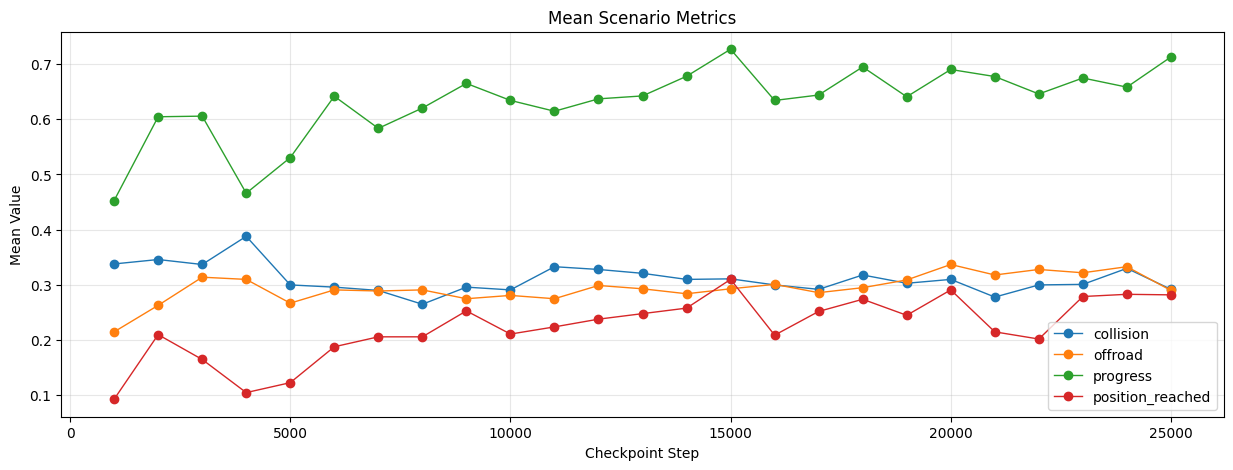

In [10]:
metric_columns = ["collision", "offroad", "progress", "position_reached"]

fig, ax = plt.subplots(figsize=(15, 5))
for metric in metric_columns:
    ax.plot(
        summary_df["checkpoint"],
        summary_df[metric],
        marker="o",
        linewidth=1,
        label=metric,
    )

ax.set_title("Mean Scenario Metrics")
ax.set_xlabel("Checkpoint Step")
ax.set_ylabel("Mean Value")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

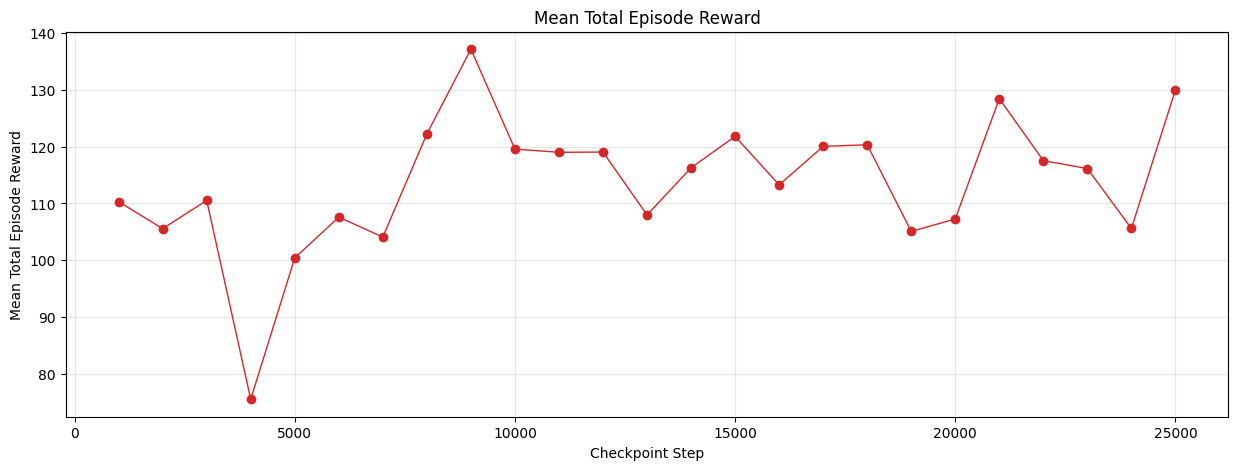

In [9]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(
    summary_df["checkpoint"],
    summary_df["total_episode_reward"],
    marker="o",
    linewidth=1,
    color="tab:red",
)

ax.set_title("Mean Total Episode Reward")
ax.set_xlabel("Checkpoint Step")
ax.set_ylabel("Mean Total Episode Reward")
ax.grid(True, alpha=0.3)
plt.show()